# Combined Model deconvolution with config types

June 13, 2024

## Goal:
Deconvolve with config_type parameter and copy number correciton

In [1]:
# Preamble, notebook setup and imports

%load_ext autoreload
%autoreload 2
%matplotlib inline
%config InlineBackend.figure_format = 'retina'

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


In [16]:
from src.CopyNumberCorrection import load_expression_copy_correction
from src.ChromatinCopyNumberCorrector import load_chromatin_copy_correction

In [102]:
from src.config import load_combined_gene_expression_by_config_type, load_configs_by_config_type

config_type = 'distinct'
combined_gene_expression_config = load_combined_gene_expression_by_config_type(config_type,
    with_copy_correction=True)
chrom_config1, chrom_config2 = load_configs_by_config_type(config_type,
    with_copy_correction=True)


In [105]:
from src.model import Model
from src.combined_chromatin_model import CombinedChromatinModel

gene_name = 'CLB2'
combined_model = CombinedChromatinModel(chrom_config1, chrom_config2)
ge_model = Model(combined_gene_expression_config, gene_name)


Applying copy number correction


In [106]:
combined_model.load_combined_mnase_gene(gene_name)

Loading MNase reads for YPR119W/CLB2...Loading chromosome reads: 16
Done.
Applying copy number correction
(16, 340) (16,)
Loading MNase reads for YPR119W/CLB2...Loading chromosome reads: 16
Done.
Applying copy number correction
(15, 340) (15,)


In [107]:
ge_model.deconvolve_find_optimal_gamma()

In [129]:
combined_model.deconvolve(gamma=0.002)

Deconvolving combined model with gamma=0.002
Deconvolving bin size: 24x24
of G shape: (31, 340)
Deconvolving with gamma=0.002
0/340 - 00:00:00.142
100/340 - 00:00:11.562
200/340 - 00:00:23.155
300/340 - 00:00:34.647
Deconvolved in : 00:00:40.297
The fitting norm is 13.58, the smoothing norm is: 51.95


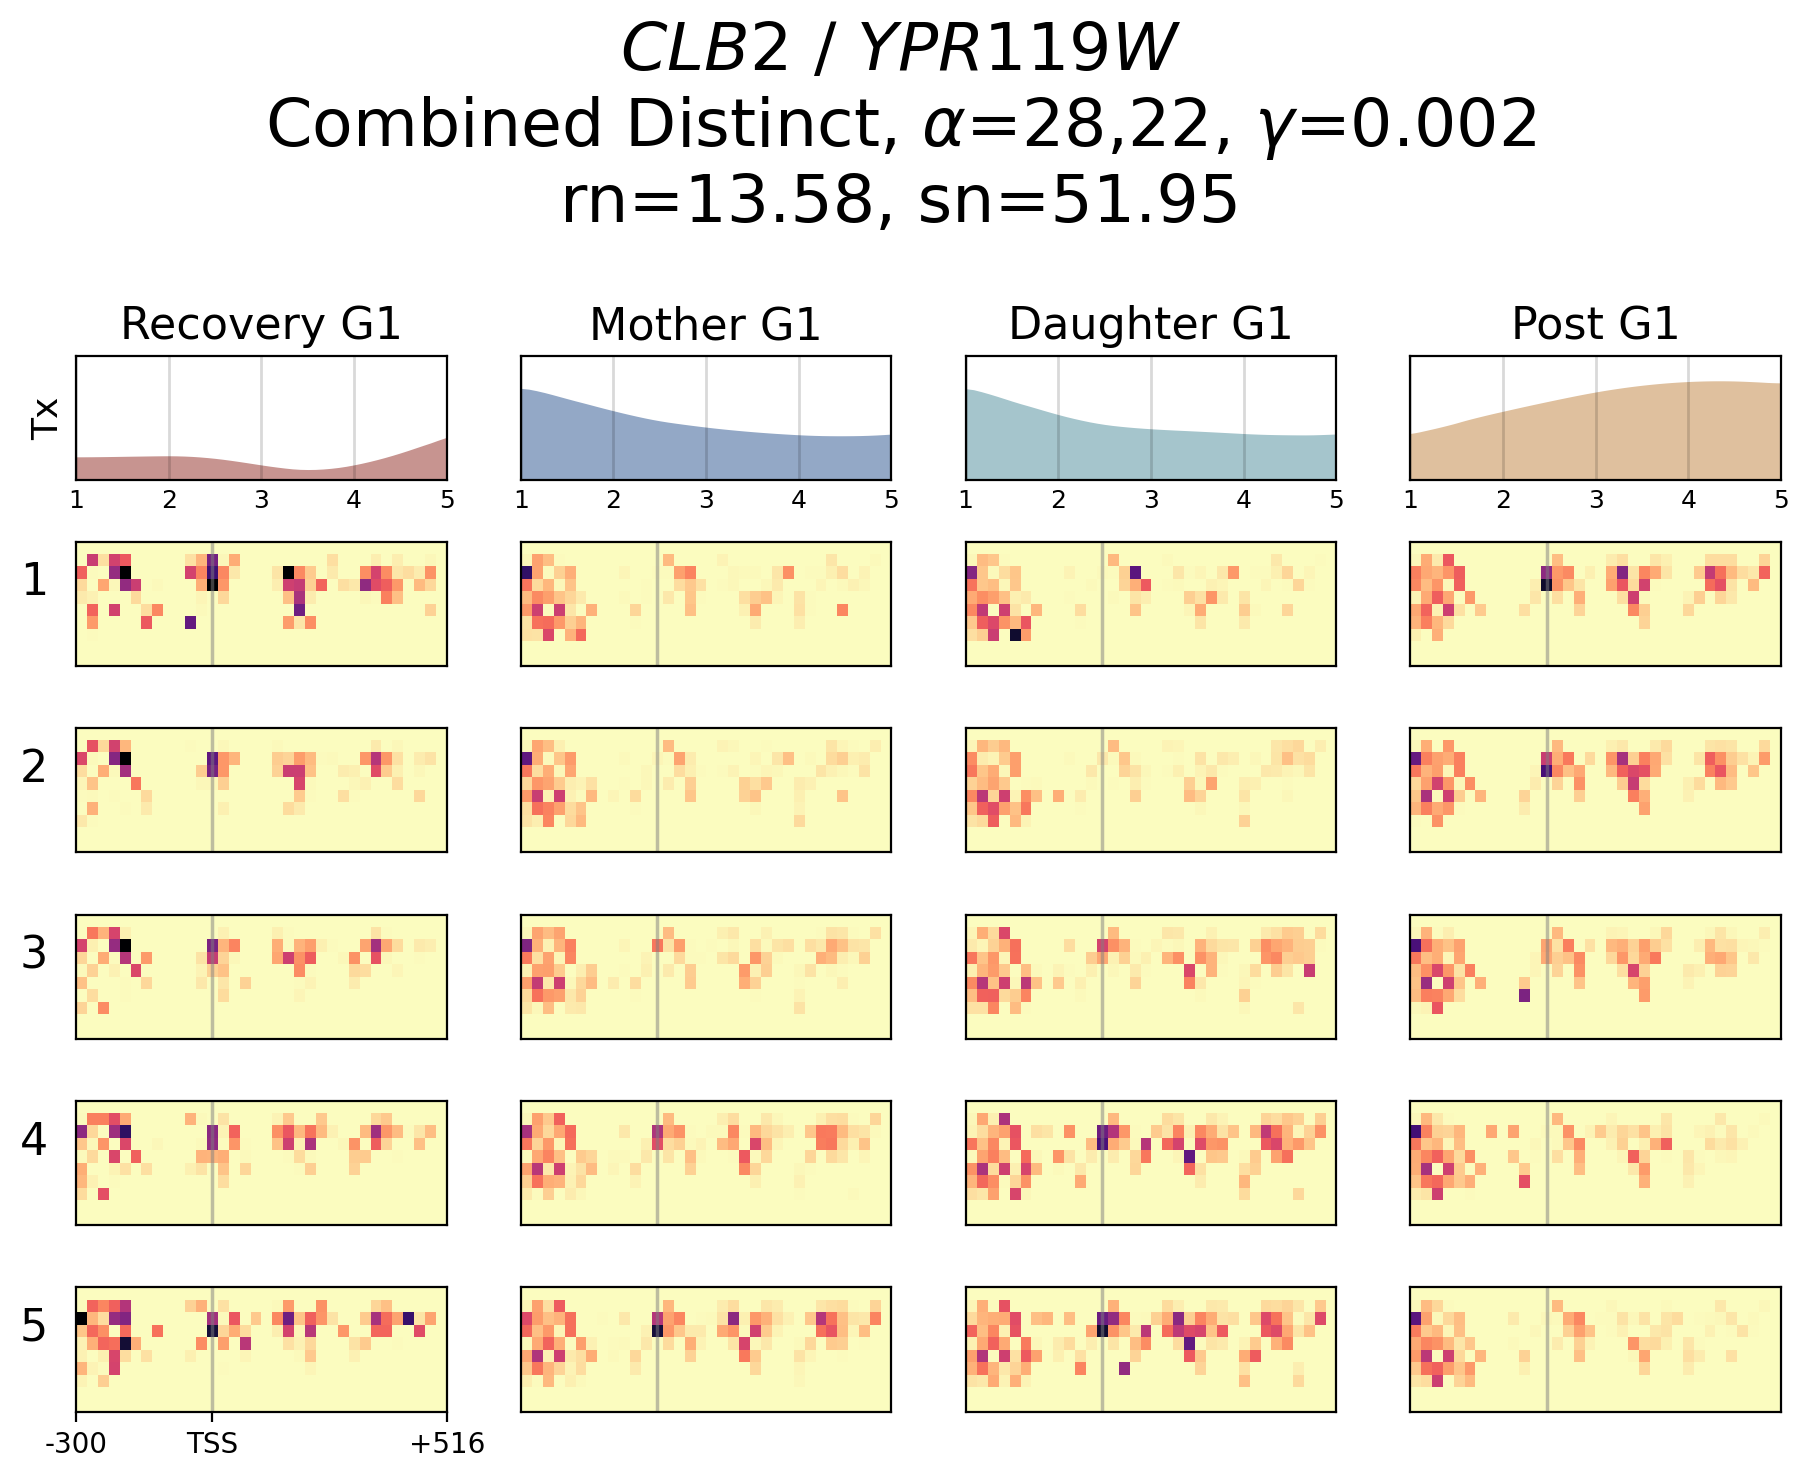

In [131]:
fig = combined_model.create_deconvolution_plots_abbreviated_flipped(ge_model)

In [132]:
combined_model.deconvolve(gamma=0.01)

Deconvolving combined model with gamma=0.01
Deconvolving bin size: 24x24
of G shape: (31, 340)
Deconvolving with gamma=0.01
0/340 - 00:00:00.119
100/340 - 00:00:11.355
200/340 - 00:00:22.704
300/340 - 00:00:34.433
Deconvolved in : 00:00:40.056
The fitting norm is 13.75, the smoothing norm is: 29.01


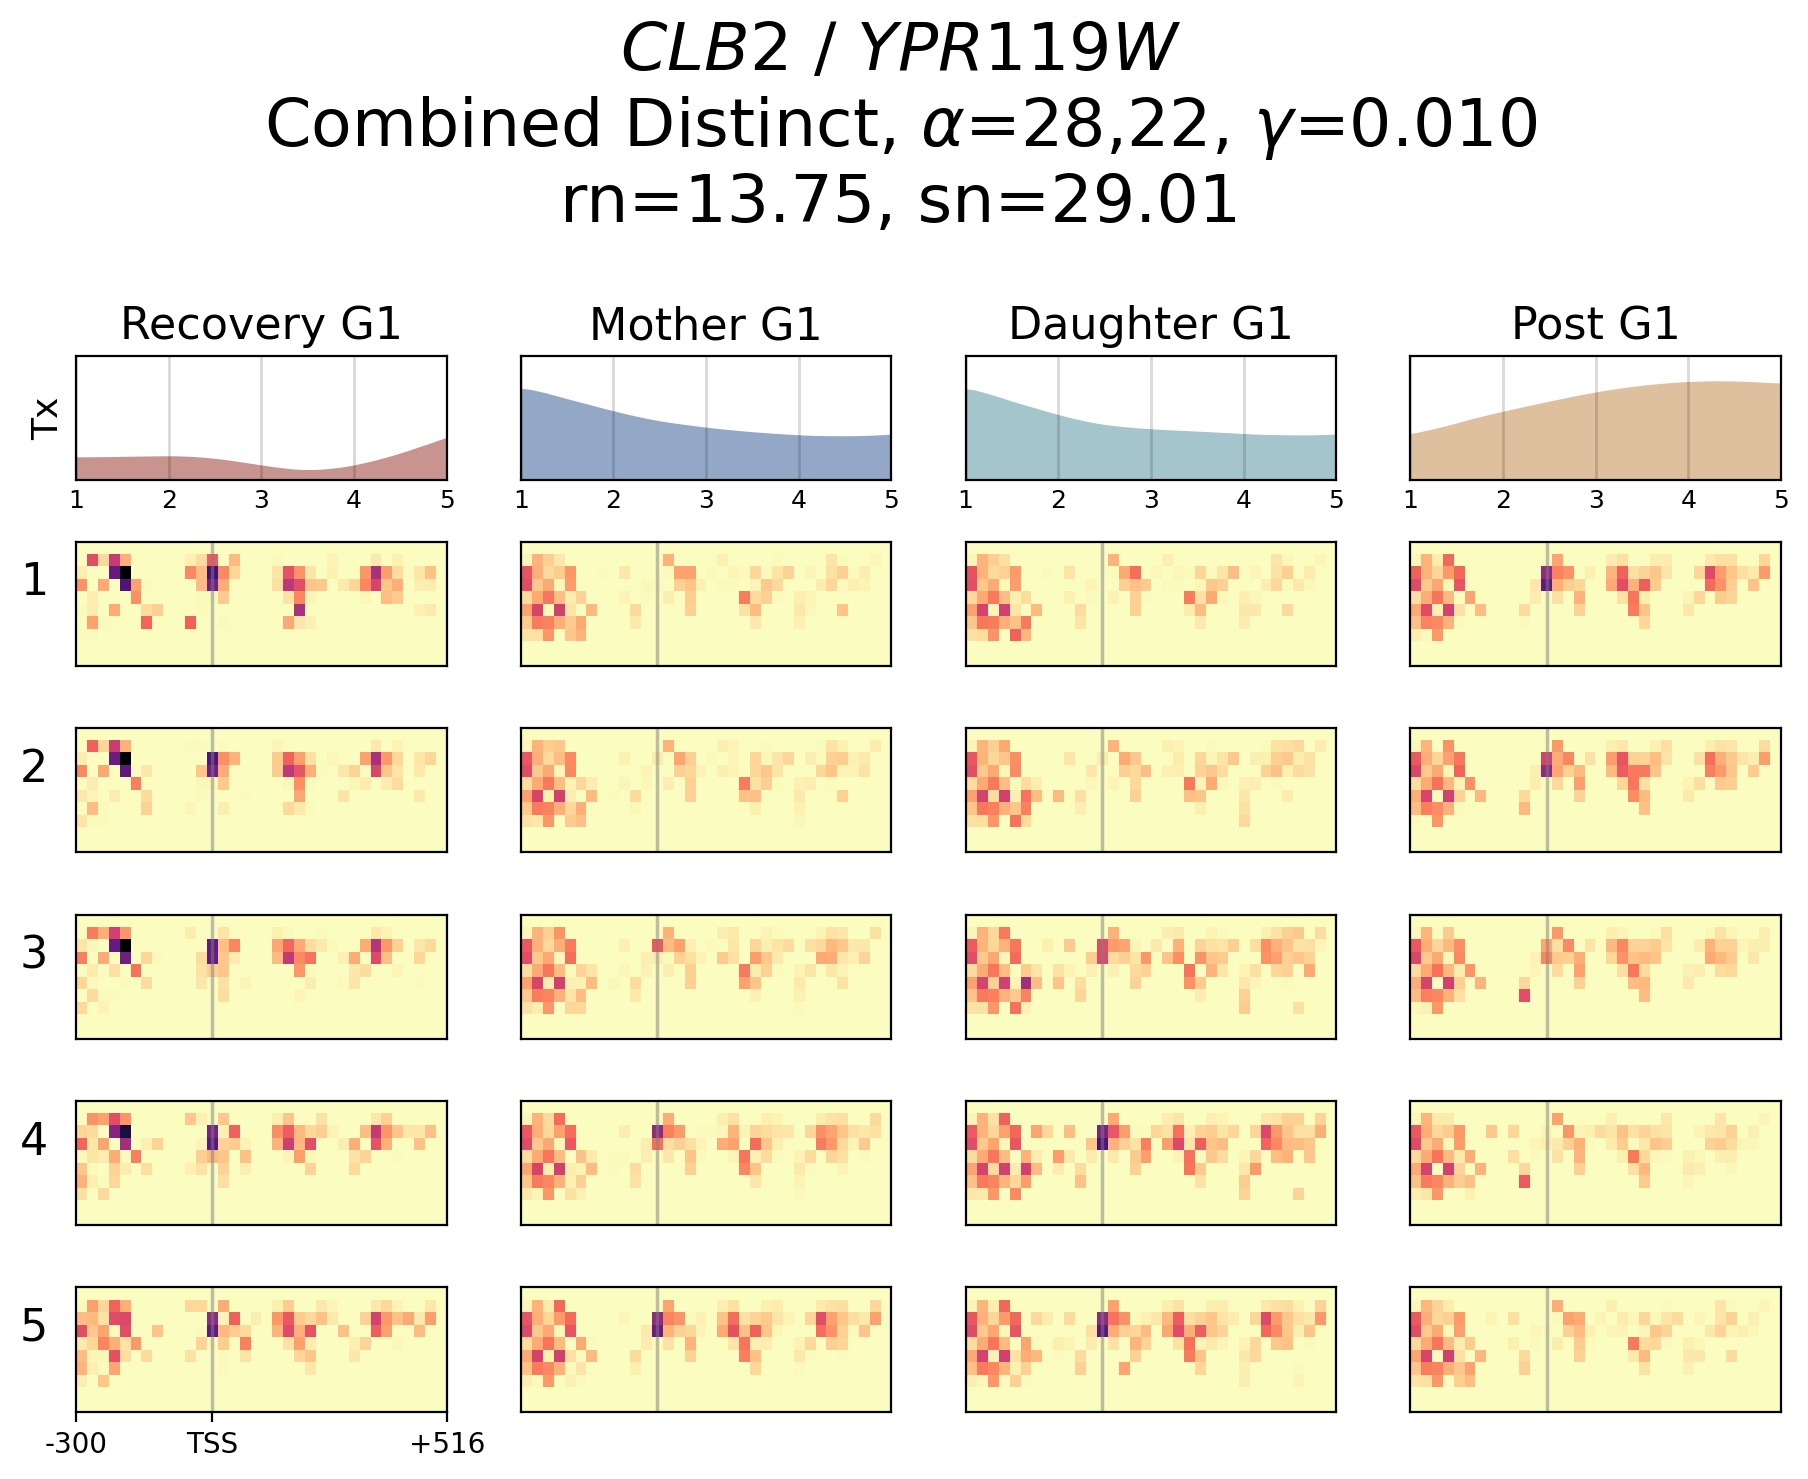

In [133]:
fig = combined_model.create_deconvolution_plots_abbreviated_flipped(ge_model)

In [113]:
import glob
from src.timer import Timer

file_paths = glob.glob(f'output/deconvolve_combined_g_opt_2024_03_14/chromatin/*_meta*')

meta_df = pd.DataFrame()
for file_path in file_paths:
    cur_df = pd.read_csv(file_path).rename(columns={'Unnamed: 0': 
        'orf_name'}).set_index('orf_name')
    meta_df = pd.concat([meta_df, cur_df])


In [119]:
file_paths = glob.glob(f'output/deconvolve_combined_delta_2024_05_27/chromatin/*_meta*')

meta_delta_df = pd.DataFrame()
for file_path in file_paths:
    cur_df = pd.read_csv(file_path).rename(columns={'Unnamed: 0': 
        'orf_name'}).set_index('orf_name')
    meta_delta_df = pd.concat([meta_df, cur_df])


Text(0.5, 1.0, 'Distinct G1 model,\nGamma values, mean=0.0066')

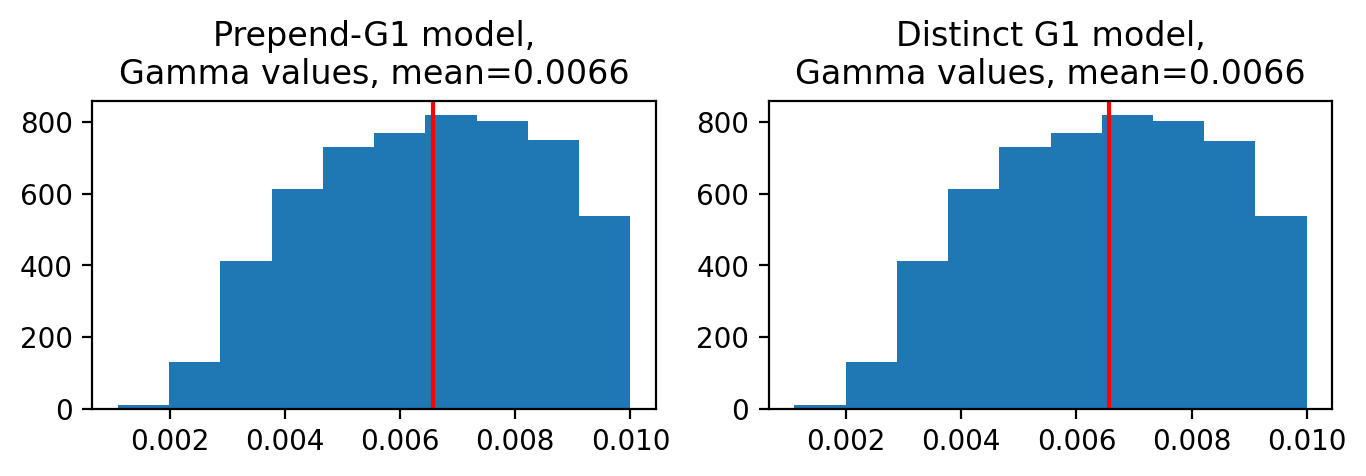

In [137]:
plt.figure(figsize=(8, 2))

plt.subplot(1, 2, 1)
plt.hist(meta_delta_df.gm)
mean_gm = meta_delta_df.gm.mean()
plt.axvline(mean_gm, c='red')
plt.title(f"Prepend-G1 model,\nGamma values, mean={mean_gm:.4f}")

plt.subplot(1, 2, 2)
plt.hist(meta_df.gm, bins=10)
mean_gm = meta_df.gm.mean()
plt.axvline(mean_gm, c='red')
plt.title(f"Distinct G1 model,\nGamma values, mean={mean_gm:.4f}")
